# 📚 10-01 · n-gram 与统计语言模型

> 目标：学完能回答「一句话出现的概率是多少」。手写 unigram/bigram/trigram 的计数与条件概率表、
> 加一/加 k/插值平滑、Perplexity 评估，在小语料上跑通「训练 → 平滑 → 评估 → 生成」完整闭环，
> 并理解马尔可夫假设如何把指数级增长的上下文压缩成可统计的计数。

> 🧩 **生活化类比**：语言模型 = 一个「接话大师」。你说"今天天气真"，它能接"好"而不是"红烧肉"——
> 靠的是统计语料里「天气真→好」出现的频率（n-gram）。它不懂语法、没有语义，只有一本巨大的
> 「词搭配账本」：哪个词后面常跟哪个词。

> 🗺️ **本篇位置**：前一篇 `00-文本表示与TF-IDF` 讲「一个词如何变成向量」；本篇讲「一串词如何算概率」
> （计数派）；后一篇 `02-Word2Vec与GloVe` 用神经网络学词向量，`03-RNN与LSTM` 解决长距离依赖。

## 主线地图：从"接话"到"打分"

```text
语言模型任务：P(一句话) = ?
        │
        ▼
① 链式法则（精确，但上下文随长度指数爆炸）
        │
        ▼
② 马尔可夫假设（截断上下文，只记最近 n-1 个词）
        │  ├─ unigram : P(w_t)
        │  ├─ bigram  : P(w_t | w_{t-1})
        │  └─ trigram : P(w_t | w_{t-2}, w_{t-1})
        ▼
③ 语料统计（numpy 计数 → 条件概率表 → 文本生成）
        │
        ▼
④ 数据稀疏：未见 n-gram → 概率 0 → 整句概率 0（本篇最核心痛点）
        │
        ▼
⑤ 平滑：加一 / 加 k / 回退 / 插值 / Kneser-Ney
        │
        ▼
⑥ Perplexity：PPL = exp(平均负对数似然)，与交叉熵 / loss 同源
        │
        ▼
⑦ 局限：窗口有限、无语义、存储爆炸 → 引出 RNN（03 篇）
```

每个环节都按同一套路展开：**直觉 → 推导 → 代码 → 局限**。

### 0.5 历史背景：从"规则派"到"统计派"的复兴

今天的语言模型（包括 GPT）看似是深度学习的产物，但"给句子算概率"这个想法，比神经网络早了半个世纪。1951 年，**克劳德·香农（Claude Shannon）**发表《Prediction and Entropy of Printed English》：他让受试者逐字母猜测英文文本的下一个字母，用"猜中率"估算英语的熵——这就是语言模型的第一次实验形态：模型越好，猜得越准。

随后的二十多年里，自然语言处理的主流是**规则派**：以乔姆斯基（Chomsky）的生成语法为代表，研究者试图用精确的文法规则"生成"全部合法句子。规则派的思路优雅，却在工程上节节败退——语言充满例外，规则永远写不完，而且无法回答"这句话到底多常见"这类频率问题。

1990 年代前后，**统计派**全面回归：IBM 的 **Frederick Jelinek** 团队在语音识别中引入统计语言模型，用"语料里数次数"替代"手写规则"，识别准确率大幅提升。学界转述过一句著名的调侃："每当我们开除一位语言学家，识别准确率就提高一点。" n-gram 正是统计派最早、最朴素也最可复现的基石——**先学会数数，再谈智能**，就是这一节的全部哲学。

## 1. 语言模型：给句子打分

### 1.1 任务定义与直觉

**语言模型（Language Model, LM）**：对任意词序列 $w_1 w_2 \cdots w_n$ 输出一个概率 $P(w_1 w_2 \cdots w_n)$，
且对所有合法句子满足 $\sum P(\text{句子}) = 1$。它不是"语法规则库"，而是一个**概率分布**。

为什么"给句子打分"这么有用？
- **生成**：从 $P(\cdot \mid \text{上文})$ 采样 → 续写、对话、写诗；
- **纠错 / 输入法**：`"天汽真好"` vs `"天气真好"`，选概率更高者；
- **语音识别**：`"今天星期四"` vs `"今天星期死"`，用 LM 给候选重排；
- **机器翻译**：多个候选译文，选 LM 打分最高的一个；
- **预训练根基**：GPT 的预训练目标就是「预测下一个词」——本质就是一个语言模型。

> 直觉：LM 不需要"懂"语言，只需要见过足够多的语料、记住「什么话更常见」。n-gram 就是最朴素的
> 记忆方式；神经网络 LM（后面的章节）只是把"记忆"换成了"参数"。

### 1.2 链式法则：从联合概率到条件概率（逐步推导）

目标是 $P(w_1 w_2 \cdots w_n)$。概率论给出一个**精确**分解：联合分布可以写成条件概率的乘积。

**第一步**：把最后一个词单独拎出来。由条件概率定义 $P(A,B) = P(B)\,P(A \mid B)$，令
$B = (w_1, \ldots, w_{n-1})$、$A = w_n$：

$$P(w_1, w_2, \ldots, w_n) = P(w_1, \ldots, w_{n-1}) \cdot P(w_n \mid w_1, \ldots, w_{n-1})$$

**第二步**：对 $P(w_1, \ldots, w_{n-1})$ 重复同样的操作，继续"剥洋葱"：

$$P(w_1, \ldots, w_{n-1}) = P(w_1, \ldots, w_{n-2}) \cdot P(w_{n-1} \mid w_1, \ldots, w_{n-2})$$

**递归到底**：不断把最后一个词剥离，直到只剩 $P(w_1)$，得到链式法则：

$$P(w_1 w_2 \cdots w_n) = \prod_{t=1}^{n} P(w_t \mid w_1 \cdots w_{t-1}), \qquad P(w_1 \mid \varnothing) = P(w_1)$$

**问题暴露**：条件 $w_1 \cdots w_{t-1}$ 的长度随 $t$ 增长。词表为 $V$ 时，长度为 $k$ 的历史共有
$V^k$ 种——**指数爆炸**。口算：$V = 10^5$ 时，$k = 3$ 就有 $10^{15}$ 种历史，任何语料都填不满。
这就是必须做近似（马尔可夫假设）的根本原因。

### 1.2 例子扩展：把"我 喜欢 学习"手算一遍链式法则

公式容易飘，动手展开一次就踏实了。设句子 $S = $ 「我 喜欢 学习」，我们要算 $P(S)$。

**第 1 层**：把最后一个词"学习"剥离（利用 $P(A,B) = P(B)\,P(A|B)$）：

$$P(\text{我 喜欢 学习}) = P(\text{我 喜欢}) \times P(\text{学习} \mid \text{我 喜欢})$$

**第 2 层**：对 $P(\text{我 喜欢})$ 再剥离"喜欢"：

$$P(\text{我 喜欢}) = P(\text{我}) \times P(\text{喜欢} \mid \text{我})$$

**合起来**，整句概率被拆成三个条件概率的连乘：

$$P(\text{我 喜欢 学习}) = P(\text{我}) \cdot P(\text{喜欢}\mid\text{我}) \cdot P(\text{学习}\mid\text{我 喜欢})$$

观察这个展开式，两件事一目了然：

1. **条件越来越长**：越靠后的词，条件里堆积的历史词越多——句子长到 20 个词，最后一个词的条件就有 19 个词；
2. **这正是稀疏的源头**：$P(\text{学习}\mid\text{我 喜欢})$ 这个条件在训练语料里很可能一次都没出现过，直接把这整句概率打成 0。所以链式法则"精确"却"不可用"，下一节马尔可夫假设就是用来"截断历史"的。

### 1.3 马尔可夫假设：只记最近 n-1 个词

**马尔可夫假设（Markov Assumption）**：当前词只依赖**最近 $n-1$ 个词**，更早的历史全部忽略：

$$P(w_t \mid w_1 \cdots w_{t-1}) \approx P(w_t \mid w_{t-n+1} \cdots w_{t-1})$$

由此得到三种常用模型（$n = 1, 2, 3$），上下文越短越容易统计、但越"近视"：

| 模型 | 假设 | 概率公式 | 理论参数规模 |
|------|------|----------|--------------|
| unigram | 词与词独立 | $P(w_t)$ | $V$ |
| bigram | 只依赖上一个词 | $P(w_t \mid w_{t-1})$ | $V^2$ |
| trigram | 依赖上两个词 | $P(w_t \mid w_{t-2}, w_{t-1})$ | $V^3$ |

**参数规模口算**：$V = 10^5$ 时 bigram 理论上有 $10^{10}$ 个参数，trigram 有 $10^{15}$ 个——
实际语料里绝大多数是 0 计数（这正是第 2 节要解决的数据稀疏问题）。

**工程记号**：句子两端加标记 $\langle s \rangle$（句首）与 $\langle /s \rangle$（句尾），例如
"我 喜欢 学习" 变成 $\langle s \rangle$ 我 喜欢 学习 $\langle /s \rangle$。这样
$P(\langle /s \rangle \mid \text{学习})$ 能表示"句子在这里结束"，生成时才知道何时停。

**最大似然估计（MLE）**：用频率估计概率——n-gram 计数除以历史计数：

$$\hat P(w_t \mid w_{t-1}) = \frac{c(w_{t-1}, w_t)}{c(w_{t-1})}$$

> 局限：这是**频率派**估计——没见过的组合概率就是 0，与"可能性"不符（见第 2 节平滑）。

### 1.3 图解 n-gram：一眼看懂窗口假设

![](images/nlp01_net_ngram.png)

**图 1：n-gram 模型示意——unigram 只看当前词，bigram 看前 1 个词，trigram 看前 2 个词；窗口越宽，上下文信息越多，但参数规模随 n 指数增长。来源：Wikimedia Commons，公有领域**

这张图把 1.3 节的"窗口"画得很直观：每个时刻，模型只"看得见"最近 n-1 个词，更早的历史一律丢弃——这正是马尔可夫假设的图形化表达。对照读图：

- **unigram（n=1）**：窗口为空，$P(w_t)$ 只依赖词本身，"我 喜欢 学习"被当成三个独立事件，完全不看邻居；
- **bigram（n=2）**：窗口装下前 1 个词，$P(w_t\mid w_{t-1})$，"喜欢→学习"这种直接搭配能被记住；
- **trigram（n=3）**：窗口装下前 2 个词，$P(w_t\mid w_{t-2},w_{t-1})$，能捕捉"我 喜欢 → 学习"这种稍长的习惯。

图里还暗含了参数规模的变化：窗口每加宽一档，可区分的历史种类就从 $V$ 涨到 $V^2$、$V^3$——图里越来越密的"分支"就是 $V^n$ 组合爆炸的视觉化。**这解释了一个工程常识：一般只用 n=2 或 3，超过 5 的 n-gram 在多数语料上几乎都因稀疏而失效。**

### 1.4 复杂度与存储

- **统计**：扫一遍语料即可，$O(N)$ 时间（$N$ 为 token 总数），用哈希表（`Counter`）累加；
- **查询**：单次条件概率查询 $O(1)$（哈希查找）；
- **存储**：不同 n-gram 数量 $\le V^n$，但实际受语料长度 $N$ 限制，且长尾严重稀疏；
- **生成**：从 $P(\cdot \mid \text{历史})$ 采样要遍历所有候选词，$O(V)$ ——词表越大生成越慢。

**数字直觉**：$V = 10^5$、$N = 10^8$ 的语料，理论 bigram 组合 $10^{10}$，实际能被观察到的
$\ll 10^8$ 个。稀疏不是偶然，是必然——这也是平滑成为 n-gram 模型"标配"的原因。

### 1.4 手算：实验 1 小语料的 unigram/bigram 计数

实验 1 要跑 unigram/bigram 统计，先用手把 5 句语料"数"一遍，代码结果才能对得上号。语料为：

```
我 喜欢 学习 自然语言处理
我 喜欢 深度 学习
他 喜欢 学习 数学
我 不 喜欢 下雨
他 喜欢 下雨 天
```

**unigram 计数（部分）**：喜欢 ×5、我 ×3、他 ×2、学习 ×3、下雨 ×2、天 ×1，总计（含 <s>/</s> 补丁）约 25 个 token。

**bigram 计数（部分高频项）**：
- (<s>, 我) = 3，(<s>, 他) = 2；
- (喜欢, 学习) = 2（句 1、句 3），(喜欢, 下雨) = 1（句 4）；
- (下雨, 天) = 1，(下雨, </s>) = 1（句 4）。

**条件概率示例**：$P(\text{学习}|\text{喜欢}) = 2/5 = 0.4$；$P(\text{下雨}|\text{喜欢}) = 1/5 = 0.2$；而 $P(\text{喜欢}|\text{下雨}) = c(\text{下雨 喜欢})/c(\text{下雨}) = 0/2 = 0$——**一个未出现的 bigram 直接给出 0 概率**，这就是实验 1 代码里那条 `assert p_bigram('喜欢','下雨') == 0.0` 想让你亲眼看到的"稀疏预警"。

In [1]:
# ---------- 实验 1：小语料 unigram/bigram 统计 + 生成 ----------
# 0) 全局配置：matplotlib 中文字体 + 随机种子
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
from collections import Counter
import os

corpus = ['我 喜欢 学习 自然语言处理',
          '我 喜欢 深度 学习',
          '他 喜欢 学习 数学',
          '我 不 喜欢 下雨',
          '他 喜欢 下雨 天']
tokens = [sent.split() for sent in corpus]

def make_ngrams(sents, n):
    """把句子序列切成 n-gram 列表（带 <s>/</s> 标记）"""
    grams = []
    for s in sents:
        seq = ['<s>'] * (n - 1) + s + ['</s>']
        grams.append([tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)])
    return grams

uni = make_ngrams(tokens, 1)   # unigram 计数
bi = make_ngrams(tokens, 2)    # bigram 计数
counts1 = Counter(g[0] for s in uni for g in s)
counts2 = Counter(g for s in bi for g in s)
total1 = sum(counts1.values())

def p_unigram(w):
    """unigram 概率：P(w) = c(w) / N"""
    return counts1[w] / total1

def p_bigram(w2, w1):
    """bigram 条件概率：P(w2|w1) = c(w1,w2) / c(w1)"""
    return counts2[(w1, w2)] / counts1[w1]

counts1['<s>'] = len(tokens)          # unigram 无句首标记，补上供生成使用

print('unigram P(喜欢) = %.3f' % p_unigram('喜欢'))
print('bigram  P(学习|喜欢) = %.3f | P(下雨|喜欢) = %.3f' %
      (p_bigram('学习', '喜欢'), p_bigram('下雨', '喜欢')))
print('bigram  P(天|下雨) = %.3f | P(喜欢|下雨) = %.3f' %
      (p_bigram('天', '下雨'), p_bigram('喜欢', '下雨')))
assert p_bigram('学习', '喜欢') > 0      # 「喜欢学习」在语料中出现 2 次
assert p_bigram('天', '下雨') > 0
assert p_bigram('喜欢', '下雨') == 0.0   # 未见 bigram：概率为 0（稀疏预警！）

# 用 bigram 生成一句话
def generate(counts2, counts1, max_len=8):
    out = ['<s>']
    for _ in range(max_len):
        w1 = out[-1]
        cands = [w2 for (a, w2) in counts2 if a == w1]
        if not cands:
            break
        probs = np.array([counts2[(w1, w2)] / counts1[w1] for w2 in cands])
        w = np.random.choice(cands, p=probs)
        if w == '</s>':
            break
        out.append(w)
    return ' '.join(out[1:])

np.random.seed(1)
for _ in range(3):
    print('生成:', generate(counts2, counts1))
print('要点：n-gram 生成只靠计数，但语料小 -> 生成空洞且重复')

unigram P(喜欢) = 0.200
bigram  P(学习|喜欢) = 0.400 | P(下雨|喜欢) = 0.400
bigram  P(天|下雨) = 0.500 | P(喜欢|下雨) = 0.000
生成: 我 不 喜欢 学习 自然语言处理
生成: 我 喜欢 学习
生成: 我 不 喜欢 下雨
要点：n-gram 生成只靠计数，但语料小 -> 生成空洞且重复


In [2]:
# ---------- 实验 1b：trigram 统计 + 条件概率表 + 生成（新增） ----------
tri = make_ngrams(tokens, 3)
counts3 = Counter(g for s in tri for g in s)

def p_trigram(w3, w1, w2):
    """trigram 条件概率：P(w3|w1,w2) = c(w1,w2,w3) / c(w1,w2)"""
    return counts3[(w1, w2, w3)] / counts2[(w1, w2)]

# 条件概率表：给定历史 (喜欢, 学习)，下一个词是什么
hist = ('喜欢', '学习')
cands = sorted({w3 for (a, b, w3) in counts3 if (a, b) == hist})
print('历史 (喜欢, 学习) 下的 trigram 条件分布：')
for w3 in cands:
    print('  P(%s | 喜欢, 学习) = %.3f' % (w3, p_trigram(w3, '喜欢', '学习')))

# 未见 trigram 演示：历史 (下雨, 天) 后面跟 <s> 出现过，跟 喜欢 没出现过
print('P(</s> | 下雨, 天) = %.2f' % p_trigram('</s>', '下雨', '天'))
print('P(喜欢 | 下雨, 天) = %.2f  <- 稀疏：语料里没有「下雨天喜欢」' %
      (counts3.get(('下雨', '天', '喜欢'), 0) / counts2[('下雨', '天')]))

# trigram 生成：第一步用 bigram 起头，之后用 trigram（上下文更长，候选更少）
def generate_trigram(max_len=8):
    cands = [w for (a, w) in counts2 if a == '<s>']
    probs = np.array([counts2[('<s>', w)] / counts1['<s>'] for w in cands])
    out = [np.random.choice(cands, p=probs)]
    hist = ['<s>', out[0]]
    for _ in range(max_len - 1):
        h = tuple(hist[-2:])
        cands = [w for (a, b, w) in counts3 if (a, b) == h]
        if not cands:
            break
        probs = np.array([counts3[(*h, w)] / counts2[h] for w in cands])
        w = np.random.choice(cands, p=probs)
        if w == '</s>':
            break
        out.append(w)
        hist.append(w)
    return ' '.join(out)

np.random.seed(7)
for _ in range(3):
    print('trigram 生成:', generate_trigram())
print('要点：trigram 上下文更长但候选更少——小语料下生成更容易"卡死"（稀疏加剧）')

历史 (喜欢, 学习) 下的 trigram 条件分布：
  P(数学 | 喜欢, 学习) = 0.500
  P(自然语言处理 | 喜欢, 学习) = 0.500
P(</s> | 下雨, 天) = 1.00
P(喜欢 | 下雨, 天) = 0.00  <- 稀疏：语料里没有「下雨天喜欢」
trigram 生成: 我 不 喜欢 下雨 天
trigram 生成: 我 喜欢 学习 自然语言处理
trigram 生成: 他 喜欢 学习 自然语言处理
要点：trigram 上下文更长但候选更少——小语料下生成更容易"卡死"（稀疏加剧）


## 2. 数据稀疏与平滑（本篇重点）

### 2.1 问题演示：未见 n-gram 概率为 0

训练语料再大也是有限的，而 n-gram 组合是 $V^n$ 级的，测试时几乎必然遇到训练里没见过的组合。
后果是灾难性的——只要一个条件概率为 0，整句概率就是 0：

$$\hat P(w_t \mid w_{t-1}) = 0 \;\Rightarrow\; P(w_1 \cdots w_n) = \prod_{t=1}^{n} \hat P(w_t \mid w_{t-1}) = 0$$

**例子**（沿用实验 1 的小语料）：「喜欢 学习」出现过 → $P(\text{学习}|\text{喜欢}) = 2/5 = 0.4$；
「下雨 学习」没出现过 → $P(\text{学习}|\text{下雨}) = 0$。若句子里有任何一个这样的词组，整句概率
就是 0——模型会"枪毙"所有含新颖搭配的合法句子。

**Zipf 定律视角**：自然语言里词频服从长尾分布，绝大多数 bigram 只出现 1 次甚至 0 次。
$V = 10^5$、$N = 10^8$ 时，可观察的 bigram 占比 $\ll 1\%$，剩下的全是 0 计数。

> 直觉：平滑 = 对"没见过"保持谦虚——给未知组合一点点概率，从高频组合里"征税"分派。

### 2.2 加一（Laplace）平滑：逐步推导

**思想**：给每个 bigram 计数 $+1$，再重新归一化。

第一步，计数变形：

$$c'(w_{i-1}, w_i) = c(w_{i-1}, w_i) + 1$$

第二步，分母要保证概率和为 1。给定历史 $w_{i-1}$，候选词共有 $V$ 个（词表大小），每个候选都 $+1$，
所以新分母 = 原计数 $c(w_{i-1})$ + $V$：

$$\hat P_{\text{Lap}}(w_i \mid w_{i-1}) = \frac{c(w_{i-1}, w_i) + 1}{c(w_{i-1}) + V}$$

**归一化验证**（关键一步，不要跳过）：

$$\sum_{w_i \in V} \frac{c(w_{i-1}, w_i) + 1}{c(w_{i-1}) + V} =
\frac{\sum_{w_i} c(w_{i-1}, w_i) + V}{c(w_{i-1}) + V} =
\frac{c(w_{i-1}) + V}{c(w_{i-1}) + V} = 1$$

其中用到了 $\sum_{w_i} c(w_{i-1}, w_i) = c(w_{i-1})$（每个历史词后面恰好跟一个词）。

**口算**：$c(\text{下雨},\text{学习})=0$、$V=12$、$c(\text{下雨})=2$ →
$\hat P = (0+1)/(2+12) = 1/14 \approx 0.071$，不再是 0。

**局限**：加一平滑把"未见过"与"见过一次"同等对待，对高频词稀释过狠；而真实语料里大部分 n-gram
恰好出现 1 次，$+1$ 会显著低估它们。

### 2.3 加 k 平滑：引入一个超参

把 $+1$ 换成 $+k$（$0 < k \le 1$ 常用）：

$$\hat P_k(w_i \mid w_{i-1}) = \frac{c(w_{i-1}, w_i) + k}{c(w_{i-1}) + k\,V}$$

- $k$ 控制"谦虚程度"：$k \to 0$ 接近原始 MLE（稀疏、尖锐）；$k$ 越大越均匀（平滑过头，PPL 变差）；
- $k$ 是超参，用**验证集**调（实验 2b 会扫 k 看效果）；
- 归一化：分母 $c(w_{i-1}) + kV$ 同样保证和为 1（推导与加一同构，把 1 换成 k 即可）。

**三种平滑的关系**：加一（$k=1$）、加 k（$k$ 可调）、以及更精细的折扣类方法——方向一致，
都是在"保留高频信息"和"给低频/未见留活路"之间做权衡。

### 2.4 回退（Backoff）与插值（Interpolation）

**回退（backoff）**：先查高阶模型，计数为 0 就"降级"到低阶（bigram 没数据退到 unigram）：

$$\hat P(w_i \mid w_{i-1}) = \begin{cases}
\dfrac{c(w_{i-1},w_i)}{c(w_{i-1})} & c(w_{i-1},w_i) > 0 \\[6pt]
\alpha(w_{i-1})\, P(w_i) & \text{否则}
\end{cases}$$

**插值（interpolation）**：不"二选一"，而是**永远加权混合**所有阶数（权重 $\lambda$ 和为 1）：

$$\hat P(w_i \mid w_{i-1}) = \lambda_1\, P_{\text{uni}}(w_i) + \lambda_2\, P_{\text{bi}}(w_i \mid w_{i-1}), \qquad \lambda_1 + \lambda_2 = 1$$

- 插值比回退更平滑、实现更简单（实验 5 会用它）；
- 高阶推广：$\lambda_1 P_{uni} + \lambda_2 P_{bi} + \lambda_3 P_{tri}$，$\sum \lambda = 1$；
- 直觉：$\lambda$ 大 = 更相信上下文；$\lambda$ 小 = 更保守、更抗稀疏。

**Kneser-Ney（面试提名字即可）**：最经典的改进——用**延续计数（continuation count）**估计低阶
概率（"这个词能接多少种不同的上文"），比纯频率更准，是 KenLM 等生产系统的默认选择。

### 2.5 平滑方法一览表（背下来）

| 方法 | 核心公式（bigram 版） | 一句话特点 | 面试点 |
|------|----------------------|-----------|--------|
| 加一 / Laplace | $\dfrac{c+1}{c(w_{i-1})+V}$ | 最简单，对高频稀释过狠 | 分母为什么是 $+V$ |
| 加 k | $\dfrac{c+k}{c(w_{i-1})+kV}$ | $k$ 用验证集调 | $k \to 0$ 回到 MLE |
| 回退 Backoff | 高阶为 0 时用低阶 | "降级"而非混合 | Katz backoff 带折扣 |
| 插值 Interpolation | $\lambda_1 P_{uni}+\lambda_2 P_{bi}$ | 永远混合各阶 | $\sum \lambda = 1$ |
| Kneser-Ney | 折扣 + 延续计数 | 最经典的生产方案 | 提名字 + 一句话原理 |

> 记忆口诀：**"平滑 = 概率质量再分配"**——从高频事件"征税"，分给低频/未见过事件，保证
> 每个合法组合概率 $> 0$ 且总和仍为 1。

### 2.5 局限与补救：平滑之后，路还敢往哪走

平滑解决了"概率为 0"，但 n-gram 模型本身还有三条硬伤，面试问"为什么后来被神经网络取代"时从这三条答：

1. **窗口有限**：$n$ 再大也记不住长距离依赖（"我昨天在图书馆…今天遇到的那本书"），$n$ 增大又引发组合爆炸；
2. **存储爆炸**：$V=10^5$、$n=3$ 理论参数 $10^{15}$，即使只存非零计数，模型文件也动辄几十 GB（KenLM 用高效索引缓解）；
3. **无语义**：n-gram 只看"表面搭配"，不知道"汽车"和"车辆"意思相近——语义信息完全缺失。

**工业界的补救路线**：
- **回退 + 插值 + Kneser-Ney**：把"没见过"的概率从低阶模型"借"，Kneser-Ney 用延续计数比纯频率更准，是 KenLM 的默认；
- **神经语言模型**：用词向量（分布式表示）把参数规模从 $O(V^n)$ 压到 $O(V \cdot d)$，参数共享让未见搭配也能泛化——这正是 02 篇 Word2Vec、03 篇 RNN 的出发点；
- **工程折中**：大规模应用常把 n-gram 与神经模型**混合**：n-gram 负责快速粗排，神经网络负责精排重打分（语音识别 N-best 重打分就是典型场景）。

> 一句话：**平滑是"缝补稀疏"，神经 LM 是"换发动机"**——本篇先把缝补手艺练熟，下一篇再换发动机。

In [3]:
# ---------- 实验 2：平滑对比（未见词组不再为 0） ----------
V = len(counts1)   # 词汇表大小（含 <s>/</s> 与全部词）

def p_bi_laplace(w2, w1, k=1.0):
    """加 k 平滑的 bigram 条件概率（k=1 即加一/Laplace）"""
    return (counts2[(w1, w2)] + k) / (counts1[w1] + k * V)

print('未见词组 P(学习|下雨) 原始=0 | 加一平滑=%.4f' % p_bi_laplace('学习', '下雨'))
print('常见词组 P(学习|喜欢) 原始=%.3f | 加一平滑=%.3f' %
      (p_bigram('学习', '喜欢'), p_bi_laplace('学习', '喜欢')))
print('概率总和（给定 w1=喜欢 的所有候选）:', round(sum(p_bi_laplace(w2, '喜欢') for w2 in counts1), 6), '（应为 1）')
assert abs(sum(p_bi_laplace(w2, '喜欢') for w2 in counts1) - 1.0) < 1e-6

# 直观展示"概率质量再分配"：常见词组被稀释，未见词组获赠概率
print('加一平滑把概率质量从高频转移到未见：')
print('  P(学习|喜欢): %.3f -> %.3f（被稀释）' % (p_bigram('学习', '喜欢'), p_bi_laplace('学习', '喜欢')))
print('  P(学习|下雨): 0 -> %.4f（获赠）' % p_bi_laplace('学习', '下雨'))
print('要点：平滑保留"可能性"，罕见组合概率小但不为 0 —— 语言模型不能给任何合法句 0 概率')

未见词组 P(学习|下雨) 原始=0 | 加一平滑=0.0714
常见词组 P(学习|喜欢) 原始=0.400 | 加一平滑=0.176
概率总和（给定 w1=喜欢 的所有候选）: 1.0 （应为 1）
加一平滑把概率质量从高频转移到未见：
  P(学习|喜欢): 0.400 -> 0.176（被稀释）
  P(学习|下雨): 0 -> 0.0714（获赠）
要点：平滑保留"可能性"，罕见组合概率小但不为 0 —— 语言模型不能给任何合法句 0 概率


In [4]:
# ---------- 实验 2b：加 k 参数扫描 + 插值平滑（新增） ----------
ks = [0.01, 0.1, 0.5, 1.0, 5.0]
print('k 越大，未见词组概率越高、常见词组被稀释越狠：')
print('  k        P(学习|下雨)   P(学习|喜欢)')
for k in ks:
    print('  %-6s   %.4f        %.4f' % (k, p_bi_laplace('学习', '下雨', k), p_bi_laplace('学习', '喜欢', k)))

# 插值（interpolation）：P_mix = λ * P_bi + (1-λ) * P_uni（两边都做加 k 平滑）
total1_full = sum(counts1.values())          # 含 <s> 的总 token 数

def p_uni_laplace(w, k=1.0):
    return (counts1[w] + k) / (total1_full + k * V)

def p_mix(w2, w1, lam, k=1.0):
    """λ 加权混合 unigram 与 bigram（λ=0 纯 unigram，λ=1 纯 bigram）"""
    return lam * p_bi_laplace(w2, w1, k) + (1 - lam) * p_uni_laplace(w2, k)

print('插值示例 λ=0.7：P_mix(学习|下雨) = 0.7*%.4f + 0.3*%.4f = %.4f' %
      (p_bi_laplace('学习', '下雨'), p_uni_laplace('学习'), p_mix('学习', '下雨', 0.7)))
assert abs(sum(p_mix(w2, '喜欢', 0.7) for w2 in counts1) - 1.0) < 1e-6
print('插值后给定历史"喜欢"的概率和 = 1.0 ✓（两种分布各归一化，加权和自然归一）')

k 越大，未见词组概率越高、常见词组被稀释越狠：
  k        P(学习|下雨)   P(学习|喜欢)
  0.01     0.0047        0.3926
  0.1      0.0312        0.3387
  0.5      0.0625        0.2273
  1.0      0.0714        0.1765
  5.0      0.0806        0.1077
插值示例 λ=0.7：P_mix(学习|下雨) = 0.7*0.0714 + 0.3*0.0952 = 0.0786
插值后给定历史"喜欢"的概率和 = 1.0 ✓（两种分布各归一化，加权和自然归一）


## 3. Perplexity：语言模型的考试分数

### 3.1 直觉：一个词有多少个"候选项"？

PPL 的中文叫**困惑度（Perplexity）**。直觉上，它回答："模型预测下一个词时，相当于在多少个词里
瞎猜？"

- PPL = 10：模型对下一个词的平均不确定性 ≈ 从 10 个词里猜；
- PPL = 1：模型完全确定（信息论下界，永不现实）；
- PPL = V：模型跟均匀分布一样，什么都没学到。

**均匀分布口算**：$V$ 个词等概率 $1/V$，每个词 $\log_2 P = \log_2(1/V)$，平均负对数 $= \log_2 V$，
所以 PPL $= 2^{\log_2 V} = V$。100 个词等概率 → PPL = 100；10 个词 → PPL = 10。

> 直觉：PPL 越小 = 模型"越不困惑"= 对下一个词的预测越集中 = 越好。它是 LM 界的"考试分数"。

### 3.2 逐步推导：PPL 与平均负对数似然、交叉熵

考虑句子 $w_1 \cdots w_N$（含句尾标记 $\langle /s \rangle$）。

**第一步**：整句概率开 $N$ 次方根取倒数——"每个词平均概率"的倒数（几何平均的倒数）：

$$\text{PPL}(w_1 \cdots w_N) = P(w_1 \cdots w_N)^{-\frac{1}{N}}$$

**第二步**：取对数把乘积变求和（条件概率乘积展开）：

$$\log_2 \text{PPL} = -\frac{1}{N} \sum_{t=1}^{N} \log_2 P(w_t \mid w_{<t})$$

**第三步**：两边去掉 $\log_2$（即 $2^{(\cdot)}$），同时换自然对数 $\log = \ln$ 写法：

$$\text{PPL} = 2^{-\frac{1}{N} \sum_t \log_2 P(w_t \mid w_{<t})}
= \exp\!\Big(-\frac{1}{N} \sum_{t} \log P(w_t \mid w_{<t})\Big)$$

**与交叉熵 / loss 的关系**（面试高频）：

$$H = -\frac{1}{N} \sum_{t=1}^{N} \log P(w_t \mid w_{<t}) \qquad\Rightarrow\qquad \text{PPL} = e^{H} = \exp(\text{loss})$$

- 交叉熵 $H$ 衡量"模型分布与真实分布的偏离"；
- 深度学习训练时 loss 通常就是交叉熵，因此 **PPL = $\exp(\text{loss})$**（同底数约定下）；
- 数字对应：loss=2.30 → PPL≈10；loss=1.61 → PPL≈5；loss=0.69 → PPL≈2。

### 3.2 信息论视角：PPL 为什么是"交叉熵的指数"

3.2 节从代数上推出 PPL = exp(H)，这里补上信息论的"为什么"——面试追问"PPL 物理意义是什么"时能多答一层。

**熵（Entropy）**：对随机变量 $X$，$H = -\sum_x P(x)\log P(x)$ 度量"平均惊讶度"——概率越均匀越惊讶，熵越大；概率集中在一个点，熵趋近 0。

**交叉熵（Cross Entropy）**：$H(p,q) = -\sum_x p(x)\log q(x)$ 用**真实分布 $p$ 的权重**去平均"模型 $q$ 的惊讶度"。语言模型里 $p$ 是语料的经验分布（每个词后面真实跟的词），$q$ 是模型预测分布。交叉熵 = $"真实世界按真实频率发生，模型却按自己的分布惊讶"$ 的平均值。

**为什么 PPL = exp(H) 是自然的选择**：
1. $H$ 单位是 bit/nat，是"平均需要几个比特编码下一个词"——**模型越好，编码越短**；
2. 取指数后变成"等效均匀分布的候选词数"——人类直觉里"10 选 1"比"2.30 nat"好懂；
3. 深度学习里的 loss 通常就是交叉熵，所以 **PPL = exp(loss)** 直接连通了 n-gram 与神经网络两个世界。

**数字对应再强调**：$H=1$ bit → PPL=2（二选一）；$H=3$ bit → PPL=8；均匀 100 词 → $H=\log_2 100≈6.64$ bit → PPL=100。**"PPL 就是平均候选词数"这句话，能串起信息论、语言模型、深度学习三者。**

### 3.3 口算练习与比较红线

**口算 1**：两个词，各 0.5 概率 → $H = -\frac{1}{2}(\log_2 0.5 + \log_2 0.5) = 1$ bit →
PPL $= 2^1 = 2$。

**口算 2**：三个词 0.5 / 0.25 / 0.25 → $H = -\frac{1}{3}(\log_2 0.5 + 2 \log_2 0.25)
= -\frac{1}{3}(-1 - 4) = \frac{5}{3}$ → PPL $= 2^{5/3} \approx 3.17$。

**比较红线（面试题：PPL 越低越好吗？）**：
- ✅ **同一语料、同一词表、同一切分**下，PPL 越低越好——这才是模型能力的比较；
- ❌ 跨语料 / 跨词表比较 PPL **无意义**：语料更易、词表更小 → PPL 天然更低，不代表模型更好
  （好比考试卷子不同，分数不能直接比）；
- PPL 高 ≠ 模型"胡言乱语"：可能是语料难度高、OOV 多、领域不匹配；
- 训练 PPL 低但测试 PPL 高 = **过拟合**信号。

### 3.4 三个评估实验的设计意图

| 实验 | 在验证什么 | 预期结果 |
|------|-----------|----------|
| 实验 3 | 手写 PPL，对比 unigram vs bigram | 覆盖句：bigram PPL 更低；未见句：未平滑 bigram PPL=inf |
| 实验 4 | 平滑修复稀疏 | 同一未见句：inf → 有限值；扫 k 看平滑程度 |
| 实验 5 | 插值平滑 + 可视化 | λ 取平衡点，PPL 最低；图看清概率质量再分配 |

注意区分三者的边界：**平滑在训练侧做，PPL 在测试侧算，测试集与训练集词表必须一致**
（未见词按 OOV 处理，见第 4 节）。

### 3.4 图解实验 5 产出：平滑 + 插值如何压低 PPL

![](images/01-ngram-smoothing-ppl.png)

**图 2：实验 5 自绘平滑 PPL 对比图——左图对比原始 MLE / 加一平滑 / 插值对同一批 bigram 概率的"再分配"，右图展示 PPL 随插值权重 λ 的变化曲线。（来源：本教程实验 5 代码自绘）**

这张图会在运行实验 5 时由代码现场生成并保存，先在这里建立"预期画面"再跑代码，对照效果加倍：

- **左图（概率再分配）**：横轴是 4 个试探词组（2 个"未见"、2 个"常见"）。看柱子高度：原始 MLE 下"未见"词组（学习|下雨、天|喜欢）柱高为 0——概率为零；加一平滑与插值把它们"抬"到正数，同时把"常见"词组的柱子略微压低——这就是"概率质量再分配"的可视化；
- **右图（λ 曲线）**：λ=0 是纯 unigram（没用上下文），λ=1 是纯 bigram（稀疏惩罚重），曲线在中间（本例 λ≈0.6~0.8）出现最低点——**插值的价值就是把 λ 调到这个平衡点**。

> 读图自检：为什么 λ 太大 PPL 反而升高？——bigram 太稀疏，λ=1 等于把概率集中压给"见过的搭配"，未见组合概率又被压回接近 0，测试句含未见词组时就崩了。

In [5]:
# ---------- 实验 3：手写 Perplexity，对比 unigram vs bigram ----------
# 严格留一：只用前 4 句训练，第 5 句的部分片段做测试
train5 = tokens[:4]
uni5 = make_ngrams(train5, 1); bi5 = make_ngrams(train5, 2)
c1 = Counter(g[0] for s in uni5 for g in s)
c1['<s>'] = len(train5)                    # unigram 无句首标记，补上供 bigram 条件概率用
c2 = Counter(g for s in bi5 for g in s)
t1 = sum(c1.values())
p1 = lambda w: c1[w] / t1
p2 = lambda w2, w1: c2[(w1, w2)] / c1[w1]

def ppl(sents, mode):
    """Perplexity = exp(-1/N * sum log P(w_i|context))；出现 0 概率则返回 inf"""
    logp, cnt = 0.0, 0
    for s in sents:
        seq = ['<s>'] + s + ['</s>']
        for i in range(1, len(seq)):
            p = p1(seq[i]) if mode == 'uni' else p2(seq[i], seq[i - 1])
            if p == 0:
                return float('inf')           # 未平滑=0：整句概率为 0，PPL=inf（演示稀疏后果）
            logp += np.log(p); cnt += 1
    return float(np.exp(-logp / cnt))

# 测试 1：训练完全覆盖的句子，bigram 应比 unigram 更准
test_covered = [['我', '喜欢', '学习']]
print('覆盖句 PPL: unigram=%.2f | bigram=%.2f（bigram 用上上下文 -> 更准）' %
      (ppl(test_covered, 'uni'), ppl(test_covered, 'bi')))
assert ppl(test_covered, 'bi') < ppl(test_covered, 'uni')

# 测试 2：词组「数学 自然语言处理」在训练里从未连用 -> bigram 概率 0 -> PPL=inf
test_unseen = [['学习', '数学', '自然语言处理']]
print('未见词组句 PPL: unigram=%.2f | 未平滑 bigram=%s（「数学|自然语言处理」没出现过 -> 0 概率）' %
      (ppl(test_unseen, 'uni'), ppl(test_unseen, 'bi')))
assert ppl(test_unseen, 'bi') == float('inf')
print('这正是必须做平滑的原因（见实验 4/5）')

覆盖句 PPL: unigram=6.93 | bigram=1.86（bigram 用上上下文 -> 更准）
未见词组句 PPL: unigram=12.89 | 未平滑 bigram=inf（「数学|自然语言处理」没出现过 -> 0 概率）
这正是必须做平滑的原因（见实验 4/5）


In [6]:
# ---------- 实验 4：平滑后 bigram 的 PPL（与未平滑对比） ----------
def ppl_laplace(sents, k=1.0):
    """用加 k 平滑的 bigram 概率计算 PPL：分母 c(w1)+k*V 保证无零概率"""
    logp, cnt = 0.0, 0
    for s in sents:
        seq = ['<s>'] + s + ['</s>']
        for i in range(1, len(seq)):
            p = (counts2[(seq[i - 1], seq[i])] + k) / (counts1[seq[i - 1]] + k * V)
            logp += np.log(p); cnt += 1
    return float(np.exp(-logp / cnt))

ppl_sm = ppl_laplace(test_unseen)
print('同一未见句「学习 数学 自然语言处理」: 未平滑 bigram PPL=%s -> 加一平滑后 PPL=%.2f' %
      (ppl(test_unseen, 'bi'), ppl_sm))
assert ppl_sm < float('inf')
assert ppl_sm < ppl(test_unseen, 'uni')

# 顺带扫 k：k 太小 -> 未见词概率过低 PPL 高；k 太大 -> 模型太平滑也变差（用验证集找平衡）
print('k 扫描（同一未见句，测试侧视角）:')
for k in [0.01, 0.1, 1.0, 10.0]:
    print('  k=%-5s PPL=%.2f' % (k, ppl_laplace(test_unseen, k)))
print('要点：平滑让所有组合概率 >0，PPL 恢复为有限值；罕见组合概率小但不为 0')

同一未见句「学习 数学 自然语言处理」: 未平滑 bigram PPL=inf -> 加一平滑后 PPL=10.19
k 扫描（同一未见句，测试侧视角）:
  k=0.01  PPL=21.05
  k=0.1   PPL=10.10
  k=1.0   PPL=10.19
  k=10.0  PPL=11.68
要点：平滑让所有组合概率 >0，PPL 恢复为有限值；罕见组合概率小但不为 0


λ 从 0（纯 unigram）到 1（纯 bigram）的 PPL 变化（测试句含未见词组）：
  λ=0.0  PPL=13.42
  λ=0.1  PPL=12.78
  λ=0.2  PPL=12.27
  λ=0.3  PPL=11.83
  λ=0.4  PPL=11.47
  λ=0.5  PPL=11.16
  λ=0.6  PPL=10.90
  λ=0.7  PPL=10.68
  λ=0.8  PPL=10.48
  λ=0.9  PPL=10.32
  λ=1.0  PPL=10.19


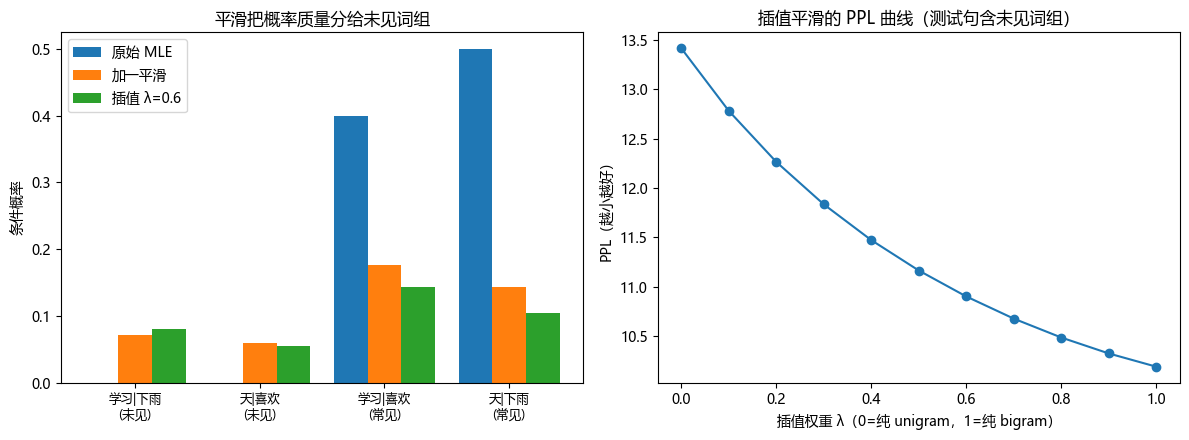

要点：λ 太小 -> 没用上上下文；λ 太大 -> 稀疏惩罚。插值在两者间取平衡（本例 λ≈0.6~0.8 最佳）


In [7]:
# ---------- 实验 5：插值平滑的 PPL + 可视化（新增） ----------
def ppl_mix(sents, lam, k=1.0):
    """插值模型（unigram+bigram 加权）的 PPL"""
    logp, cnt = 0.0, 0
    for s in sents:
        seq = ['<s>'] + s + ['</s>']
        for i in range(1, len(seq)):
            p = p_mix(seq[i], seq[i - 1], lam, k)
            logp += np.log(p); cnt += 1
    return float(np.exp(-logp / cnt))

print('λ 从 0（纯 unigram）到 1（纯 bigram）的 PPL 变化（测试句含未见词组）：')
lams = np.linspace(0, 1, 11)
ppls = [ppl_mix(test_unseen, float(lam)) for lam in lams]
for lam, p in zip(lams, ppls):
    print('  λ=%.1f  PPL=%.2f' % (lam, p))

# 可视化 1：不同平滑策略对同一组 bigram 概率的再分配
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pairs = [('学习', '下雨'), ('天', '喜欢'), ('学习', '喜欢'), ('天', '下雨')]
labels = ['学习|下雨\n(未见)', '天|喜欢\n(未见)', '学习|喜欢\n(常见)', '天|下雨\n(常见)']
raw = [p_bigram(w2, w1) for (w2, w1) in pairs]
lap = [p_bi_laplace(w2, w1, 1.0) for (w2, w1) in pairs]
mix = [p_mix(w2, w1, 0.6) for (w2, w1) in pairs]
x = np.arange(len(pairs)); wdt = 0.27
axes[0].bar(x - wdt, raw, wdt, label='原始 MLE')
axes[0].bar(x, lap, wdt, label='加一平滑')
axes[0].bar(x + wdt, mix, wdt, label='插值 λ=0.6')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('条件概率'); axes[0].set_title('平滑把概率质量分给未见词组')
axes[0].legend()

# 可视化 2：PPL 随插值权重 λ 变化
axes[1].plot(lams, ppls, 'o-')
axes[1].set_xlabel('插值权重 λ（0=纯 unigram，1=纯 bigram）')
axes[1].set_ylabel('PPL（越小越好）')
axes[1].set_title('插值平滑的 PPL 曲线（测试句含未见词组）')
os.makedirs(os.path.join('10-自然语言处理', '教学', 'images'), exist_ok=True)
fig.tight_layout()
fig.savefig(os.path.join('10-自然语言处理', '教学', 'images', '01-ngram-smoothing-ppl.png'), dpi=110)
plt.show()
print('要点：λ 太小 -> 没用上上下文；λ 太大 -> 稀疏惩罚。插值在两者间取平衡（本例 λ≈0.6~0.8 最佳）')

## 4. 数字敏感度与易错点（面试官爱问的坑）

1. **PPL 与 loss 的底数**：PPL = $\exp(\text{loss})$（自然底数），或 $2^{-\frac1N \sum \log_2 P}$
   （以 2 为底）。换算前先确认底数，别把 $\log_2$ 和 $\ln$ 混用（两者结果差 $\ln 2$ 倍）。
2. **加 k 的分母是 $c(w_{i-1}) + k\,V$，不是 $+V$**：每个候选都加 k，总增量是 $kV$；
   写错成 $+V$ 概率和就不是 1（实验 2 有断言兜底）。
3. **`<s>` 与 `</s>` 都要进计数**：漏 `<s>` 会导致首词条件概率分母对不上；漏 `</s>` 会让模型
   "永远不想结束"（生成停不下来，PPL 也被低估）。
4. **PPL 对零概率极敏感**：只要一个条件概率为 0，整句 $\log$ 变 $-\infty$ → PPL=inf。
   评估前必须确保平滑 / OOV 兜底。
5. **OOV（未登录词）**：测试句里的新词要映射到保留的 `<unk>` token（训练时留出词表位置），
   否则直接 0 概率；好的做法：训练时把低频词替换为 `<unk>`。
6. **平滑与评估的边界**：平滑参数（k、λ）在**训练侧**用验证集调；测试集只能出现一次，
   不能边测边调（避免过拟合评估）。

### 4.5 面试追问（进阶题，答出即加分）

1. **Q：为什么加 k 平滑的 k 常用 0<k≤1，很少大于 1？** A：k>1 意味着"每个未见组合分到的概率和见过一次的相当"，会把高频词严重稀释；k 实质是"给未见的信任度"，宁小勿大。
2. **Q：回退与插值哪个更好？** A：理论上前者更省存储（计算时才降级），后者永远混合、数值更平滑且训练更简单；工程上两者可结合（Kneser-Ney 就是"折扣 + 回退"）。
3. **Q：语料里不存在 `<unk>`，测试遇到新词怎么办？** A：训练时把低频词替换为 `<unk>` 并留出词表位；测试时新词一律映射 `<unk>`——纯 n-gram 没有词向量扩展能力，这是它的固有短板。
4. **Q：PPL=2 与 PPL=4 的差距有多大？** A：PPL 是 exp 尺度，2→4 意味着平均候选词数翻倍、平均每词多错 1 bit——差别相当显著，不要被线性直觉骗了。
5. **Q：为什么同一模型在两个语料上 PPL 天差地别？** A：语料难度、词表大小、句长分布都影响 PPL，"跨语料比 PPL"是统计误用，只有同语料同词表同切分才可比。

## 5. 面试速答（30 秒背诵版）

- **Q：n-gram 语言模型是什么？** A：假设当前词只依赖最近 n-1 个词，用计数频率估计条件概率的
  统计模型：$P(w_t \mid w_{t-1}) = c(w_{t-1},w_t)/c(w_{t-1})$。
- **Q：为什么要平滑？** A：数据稀疏 → 未见 n-gram 概率为 0 → 整句概率为 0；平滑 = 把概率质量
  从高频分给低频/未见，保证所有合法句概率 > 0。
- **Q：加一 / 加 k 平滑公式？** A：$(c+k)/(c(w_{i-1})+kV)$；$k=1$ 即 Laplace；$k$ 用验证集调。
- **Q：回退 vs 插值？** A：回退是"高阶没数据才用低阶"；插值是永远按 λ 加权混合各阶，$\sum\lambda=1$。
- **Q：PPL 公式与含义？** A：$\text{PPL} = \exp(-\frac1N\sum_t \log P(w_t\mid w_{<t}))
  = \exp(\text{交叉熵}) = \exp(\text{loss})$；越小越好；均匀分布时 PPL = V。
- **Q：PPL 越低越好吗？** A：只在同一语料 / 词表 / 切分下成立；跨语料比较无意义。
- **Q：OOV 怎么处理？** A：训练时留 `<unk>` 位、低频词替换为 `<unk>`；测试时未见词映射 `<unk>`。
- **Q：n-gram 的局限？** A：窗口有限（长距离依赖）、数据稀疏、无语义、存储 $O(V^n)$
  → 神经 LM 用参数共享 + 分布式表示解决。

## 6. 自测清单

- [ ] 默写链式法则与 bigram 概率公式（含 `<s>` / `</s>` 标记）
- [ ] 手写 unigram/bigram/trigram 计数与条件概率（numpy + Counter）
- [ ] 口算：count=0、V=12、c(历史)=2 时加一平滑概率 = 1/14
- [ ] 推导加一平滑分母为什么是 $c(w_{i-1}) + V$（归一化验证）
- [ ] 手写 Perplexity，说清与平均负对数似然、交叉熵、loss 的关系
- [ ] 口算：均匀分布 100 词 → PPL=100；两词各 0.5 → PPL=2
- [ ] 说出平滑的四种方法（加一 / 加 k / 回退 / 插值）与 Kneser-Ney 的名字
- [ ] 说清 PPL 比较的三条红线（同语料、同词表、同切分）
- [ ] 说清 OOV 为什么不能直接给 0 概率、`<unk>` 的作用
- [ ] 说清 n-gram 三大局限与神经网络 LM 的对应改进

### 6.5 延伸阅读与知识图谱

**本篇在课程中的位置**：00（文本表示/TF-IDF）→ **01（n-gram 与统计 LM）** → 02（Word2Vec/GloVe）→ 03（RNN/LSTM）→ 04（Transformer）→ 05（预训练模型）。

**知识图谱（相关概念串联）**：

```
信息论：熵 H / 交叉熵 / 惊讶度 -log P
   │
   ▼
语言模型 P(句子) ──► 链式法则 ──► 马尔可夫假设 ──► n-gram
   │                                     │
   │                      ┌── 平滑：加一/加k/回退/插值/KN
   │                      └── 稀疏：Zipf 长尾 → 0 概率问题
   ▼
PPL = exp(平均负对数似然) = exp(交叉熵) = exp(loss)
   │
   ▼
神经 LM：词向量（02 篇）→ RNN 隐状态（03 篇）→ Transformer（04/05 篇）
```

**延伸阅读建议**：
- Shannon（1951）《Prediction and Entropy of Printed English》——语言模型最早的实验与熵的估算；
- Jelinek 的经典教材《Statistical Methods for Speech Recognition》——统计语言模型的教科书出处；
- Chen & Goodman（1999）《An Empirical Study of Smoothing Techniques for Language Modeling》——五种平滑方法的系统对比，面试被问"为什么 KN 最好"的权威答案；
- GPT 系列论文的 loss/PPL 曲线——看"预训练 = 语言建模"在现代大模型里的延续。

**复利效应提醒**：PPL=exp(loss) 这个等式在本篇只值一行，但到 05 篇看 BERT/GPT 的训练曲线时，你会反复用到——**现在把"交叉熵 ↔ PPL ↔ loss"三位一体焊死，后面每一章都少疼一次**。

## 7. 下一篇预告

n-gram 靠"计数"建模语言：窗口有限、无语义、存储爆炸。下一篇 `02-Word2Vec与GloVe` 把词变成
分布式向量，用神经网络概率化；`03-RNN与LSTM` 解决长距离依赖——「接话大师」从账本进化成
有"记忆"的神经网络。